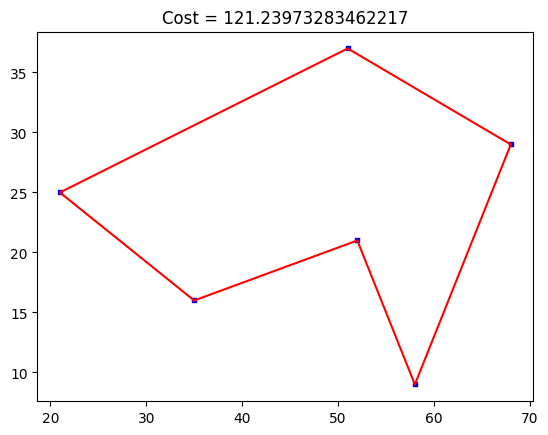

[1, 4, 5, 3, 2, 6] 121.23973283462217


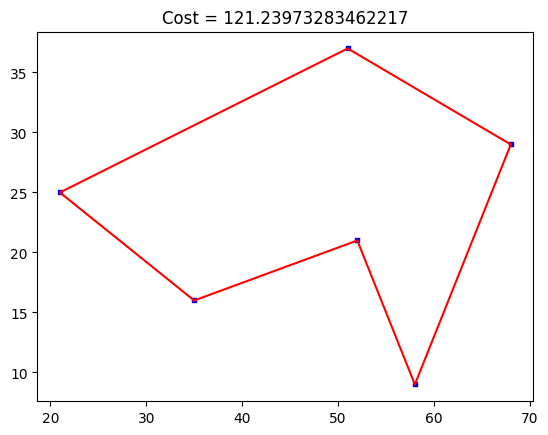

[1, 6, 2, 3, 5, 4] 121.23973283462217


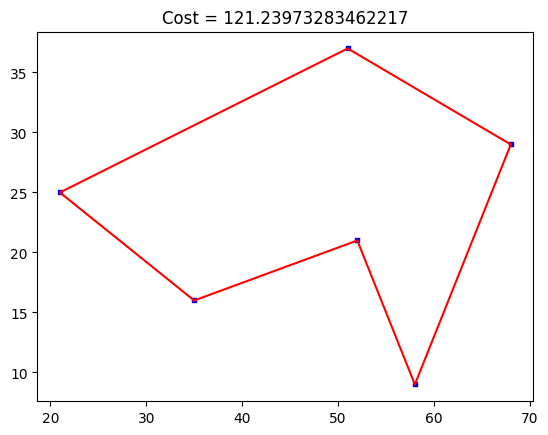

[1, 4, 5, 3, 2, 6] 121.23973283462217


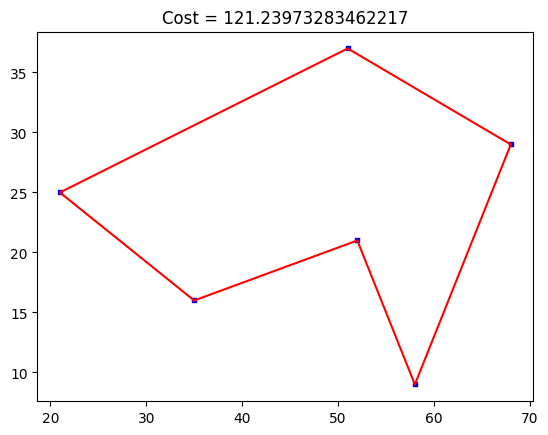

[1, 4, 5, 3, 2, 6] 121.23973283462217


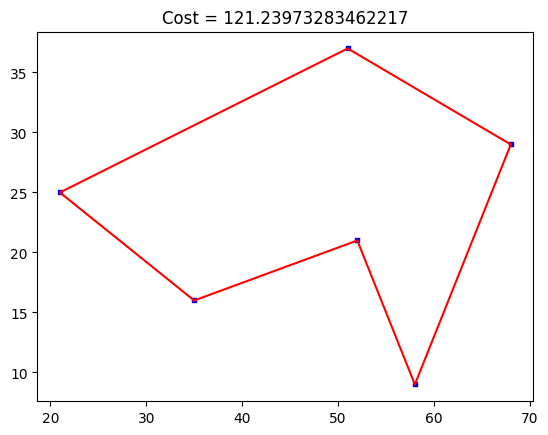

[1, 6, 2, 3, 5, 4] 121.23973283462217


In [7]:
###Example of a Genetic Algirthm for TSP

# PART 1 = Creates the Distance Matrix
# PART 2 = Plots the optimial route on a map.
# PART 3 = Calculates the distance of a given path
# PART 4 = Main GA parameters (Probability of creating each type of child)
# PART 5 = Carries out a Crossover
# PART 6 = Carries out a Mutation
# PART 7 = Selects the fittest parents
# PART 8 = Creates the new population for the next generation
# PART 9 = number of generations
# PART 10 =  Input the data for the problem
# PART 11 = Run the main GA (including population size)


import sys, math, random, heapq
import matplotlib.pyplot as plt
from itertools import chain

if sys.version_info < (3, 0):
   sys.exit("""Sorry, requires Python 3.x, not Python 2.x.""")

class Graph:

    def __init__(self, vertices):
        self.vertices = vertices
        self.n = len(vertices)

    def x(self, v):
        return self.vertices[v][0]

    def y(self, v):
        return self.vertices[v][1]

    # Lookup table for distances
    _d_lookup = {}

###########################################################################
##### PART 1: Converts grid co-ordinates of the nodes into a distance matrix

    def d(self, u, v):
        # Check if the distance was computed before
        if (u, v) in self._d_lookup:
            return self._d_lookup[(u, v)]
        # Otherwise compute euclidean distance
        _distance = math.sqrt((u[0] - v[0])**2 + (u[1] - v[1])**2)
        # Add to dictionary
        self._d_lookup[(u, v)], self._d_lookup[(v, u)] = _distance, _distance
        return _distance

###########################################################################
##### PART 2: Plots the final optimal route

    def plot(self, tour=None):
        """Plots the cities and superimposes given tour"""
        if tour is None:
            tour = Tour(self, [])

        _vertices = [self.vertices[0]]

        for i in tour.vertices:
            _vertices.append(self.vertices[i])

        _vertices.append(self.vertices[0])

        plt.title("Cost = " + str(tour.cost()))
        plt.plot(*zip(*_vertices), '-r')
        plt.scatter(*zip(*self.vertices), c="b", s=10, marker="s")
        plt.show()

###########################################################################
##### PART 3: Calculates the distance of a given (full) path
class Tour:

    def __init__(self, g, vertices = None):
        """Generate random tour in given graph g"""
        self.g = g
        if vertices is None:
            self.vertices = list(range(1, g.n))
            random.shuffle(self.vertices)
        else:
            self.vertices = vertices
        self.__cost = None

    def cost(self):
        """Return total edge-cost of tour"""
        if self.__cost is None:
            self.__cost = 0
            for i, j in zip([0] + self.vertices, self.vertices + [0]):
                self.__cost += self.g.d(self.g.vertices[i], self.g.vertices[j])
        return self.__cost

###########################################################################
##### PART 4: IMPORTANT Main GA parameters (Probability of creating each type of child)

class GeneticAlgorithm:

    def __init__(self, g, population_size, k=10, elite_mating_rate=0.2,
                 mutation_rate=0.2, mutation_swap_rate=0.2):   #Probability of each type of child being created
        """Initialises algorithm parameters"""

        self.g = g

        self.population = []
        for _ in range(population_size):
            self.population.append(Tour(g))

        self.population_size = population_size
        self.k = k
        self.elite_mating_rate = elite_mating_rate
        self.mutation_rate = mutation_rate
        self.mutation_swap_rate = mutation_swap_rate

###########################################################################
##### PART 5 = Crossover - as described in Teaching Material (Week 11 = AI)

    def crossover(self, mum, dad):
        """Implements ordered crossover"""

        size = len(mum.vertices)

        # Choose random start/end position for crossover
        alice, bob = [-1] * size, [-1] * size
        start, end = sorted([random.randrange(size) for _ in range(2)])

        # Replicate mum's sequence for alice, dad's sequence for bob
        for i in range(start, end + 1):
            alice[i] = mum.vertices[i]
            bob[i] = dad.vertices[i]

        # Fill the remaining position with the other parents' entries
        current_dad_position, current_mum_position = 0, 0

        for i in chain(range(start), range(end + 1, size)):

            while dad.vertices[current_dad_position] in alice:
                current_dad_position += 1

            while mum.vertices[current_mum_position] in bob:
                current_mum_position += 1

            alice[i] = dad.vertices[current_dad_position]
            bob[i] = mum.vertices[current_mum_position]

        # Return twins
        return Tour(self.g, alice), Tour(self.g, bob)

###########################################################################
##### PART 6 = Mutation - swaps pairs, as in TSP_HillClimb.py and described in Week 10, but can swap multiple pairs.
    def mutate(self, tour):
        """Randomly swaps pairs of cities in a given tour according to mutation rate"""

        # Decide whether to mutate
        if random.random() < self.mutation_rate:

            # For each vertex
            for i in range(len(tour.vertices)):

                # Randomly decide whether to swap node i
                if random.random() < self.mutation_swap_rate:

                    # Randomly choose other node to swap j
                    j = random.randrange(len(tour.vertices))

                    # Swap i and j
                    tour.vertices[i], tour.vertices[j] = tour.vertices[j], tour.vertices[i]

###########################################################################
##### PART 7 = Selects the fittest parents = takes a random sample of solutions and picks "best" solutions from that sample
    def select_parent(self, k):
        """Implements k-tournament selection to choose parents"""
        tournament = random.sample(self.population, k)
        return max(tournament, key=lambda t: t.cost())


###########################################################################
##### PART 8 = Creates the new population for the next generation

    def evolve(self):
        """Executes one iteration of the genetic algorithm to obtain a new generation"""

        new_population = []

        for _ in range(self.population_size):

            # K-tournament for parents
            mum, dad = self.select_parent(self.k), self.select_parent(self.k)
            alice, bob = self.crossover(mum, dad)

            # keep children if better than a parent
            if random.random() < self.elite_mating_rate:
                if alice.cost() < mum.cost() or alice.cost() < dad.cost():
                    new_population.append(alice)
                if bob.cost() < mum.cost() or bob.cost() < dad.cost():
                    new_population.append(bob)

            else:
                self.mutate(alice)
                self.mutate(bob)
                new_population += [alice, bob]

        # Add new population to old
        self.population += new_population

        # Take the fittest individuals in population, including Elitism
        self.population = heapq.nsmallest(self.population_size, self.population, key=lambda t: t.cost())

###########################################################################
##### PART 9 = IMPORTANT ##### number of generations = (similar to number of steps in hill-climb)

    def run(self, iterations=3500):  #Number of Generations: more = better, but takes longer
        for _ in range(iterations):
            self.evolve()

    def best(self):
        return max(self.population, key=lambda t: t.cost())

###########################################################################
##### PART 10 =  IMPORTANT ## Input the data for the problem

#Practical 9, Question 1
g = Graph([
(35,16),     # 1
#(90,92),    # 2
#(25,82),    # 3
#(95,77),    # 4
#(85,85),    # 5
(51,37),     # 6
#(46,68),    # 7
#(31,43),    # 8
#(71,40),    # 9
#(91,68),    # 10
(68,29),     # 11
(52,21),     # 12
#(57,44),    # 13
#(11,10),    # 14
#(41,45),    # 15
#(34,87),    # 16
#(26,41),    # 17
#(47,60),    # 18
(58,9),      # 19
#(27,12),    # 20
#(9,92),     # 21
#(95,60),    # 22
#(23,64),    # 23
(21,25),     #W1
#(37,70),     #W2
])

###########################################################################
##### PART 11 = IMPORTANT ## Runs the main GA (including population size)

for _ in range(5):  #Runs the GA 5 times
    ga = GeneticAlgorithm(g, 900)    #Inputs (graph co-ordinates, POPULATION SIZE)  more = better, but takes longer
    ga.run()


    ########## Output

    best_tour = ga.best()
    g.plot(best_tour)   #Plots the path on a graph

    best_path = best_tour.vertices
    size = len (g.vertices)
    for i in range(size-1):
        best_path[i]=best_path[i]+1   #Must +1 to nodes to chnage numbering from (0,n-1) to (1,n)
    best_path.insert(0,1)   #Adds start node to the list
    print(best_path,best_tour._Tour__cost)   #Prints the best path and distance

# W1 - Van 1. Route: W1 - 1 - 12 - 19 - 11 - 6 - W1 #
## Best: 121.239 ##

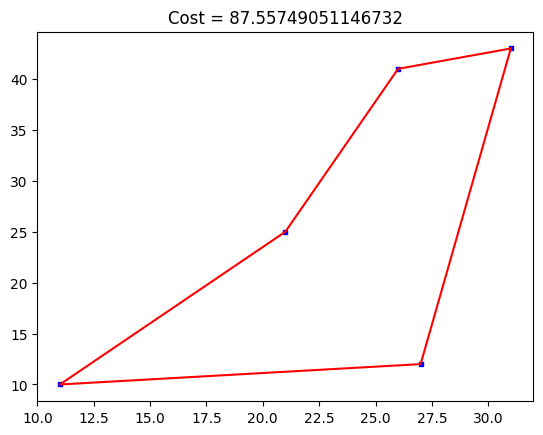

[1, 4, 2, 5, 3] 87.55749051146732


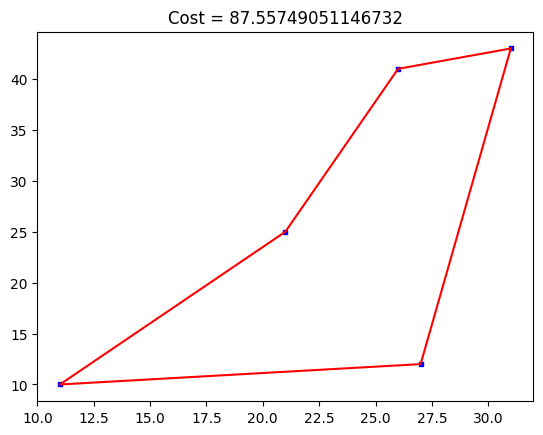

[1, 4, 2, 5, 3] 87.55749051146732


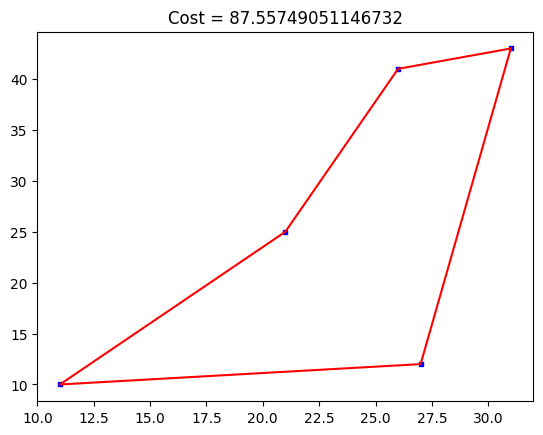

[1, 4, 2, 5, 3] 87.55749051146732


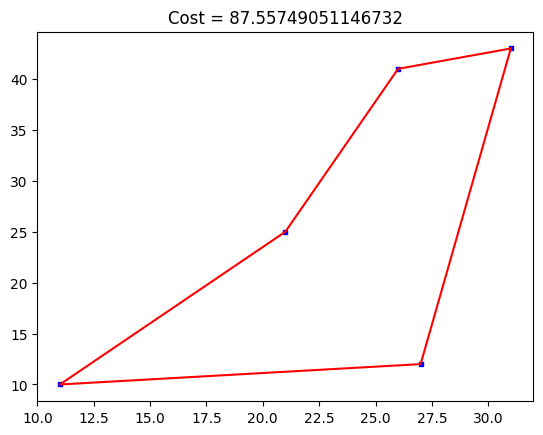

[1, 4, 2, 5, 3] 87.55749051146732


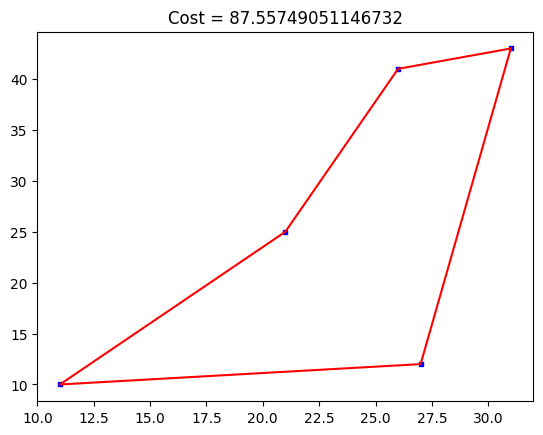

[1, 4, 2, 5, 3] 87.55749051146732


In [8]:
###Example of a Genetic Algirthm for TSP

# PART 1 = Creates the Distance Matrix
# PART 2 = Plots the optimial route on a map.
# PART 3 = Calculates the distance of a given path
# PART 4 = Main GA parameters (Probability of creating each type of child)
# PART 5 = Carries out a Crossover
# PART 6 = Carries out a Mutation
# PART 7 = Selects the fittest parents
# PART 8 = Creates the new population for the next generation
# PART 9 = number of generations
# PART 10 =  Input the data for the problem
# PART 11 = Run the main GA (including population size)


import sys, math, random, heapq
import matplotlib.pyplot as plt
from itertools import chain

if sys.version_info < (3, 0):
   sys.exit("""Sorry, requires Python 3.x, not Python 2.x.""")

class Graph:

    def __init__(self, vertices):
        self.vertices = vertices
        self.n = len(vertices)

    def x(self, v):
        return self.vertices[v][0]

    def y(self, v):
        return self.vertices[v][1]

    # Lookup table for distances
    _d_lookup = {}

###########################################################################
##### PART 1: Converts grid co-ordinates of the nodes into a distance matrix

    def d(self, u, v):
        # Check if the distance was computed before
        if (u, v) in self._d_lookup:
            return self._d_lookup[(u, v)]
        # Otherwise compute euclidean distance
        _distance = math.sqrt((u[0] - v[0])**2 + (u[1] - v[1])**2)
        # Add to dictionary
        self._d_lookup[(u, v)], self._d_lookup[(v, u)] = _distance, _distance
        return _distance

###########################################################################
##### PART 2: Plots the final optimal route

    def plot(self, tour=None):
        """Plots the cities and superimposes given tour"""
        if tour is None:
            tour = Tour(self, [])

        _vertices = [self.vertices[0]]

        for i in tour.vertices:
            _vertices.append(self.vertices[i])

        _vertices.append(self.vertices[0])

        plt.title("Cost = " + str(tour.cost()))
        plt.plot(*zip(*_vertices), '-r')
        plt.scatter(*zip(*self.vertices), c="b", s=10, marker="s")
        plt.show()

###########################################################################
##### PART 3: Calculates the distance of a given (full) path
class Tour:

    def __init__(self, g, vertices = None):
        """Generate random tour in given graph g"""
        self.g = g
        if vertices is None:
            self.vertices = list(range(1, g.n))
            random.shuffle(self.vertices)
        else:
            self.vertices = vertices
        self.__cost = None

    def cost(self):
        """Return total edge-cost of tour"""
        if self.__cost is None:
            self.__cost = 0
            for i, j in zip([0] + self.vertices, self.vertices + [0]):
                self.__cost += self.g.d(self.g.vertices[i], self.g.vertices[j])
        return self.__cost

###########################################################################
##### PART 4: IMPORTANT Main GA parameters (Probability of creating each type of child)

class GeneticAlgorithm:

    def __init__(self, g, population_size, k=10, elite_mating_rate=0.2,
                 mutation_rate=0.2, mutation_swap_rate=0.2):   #Probability of each type of child being created
        """Initialises algorithm parameters"""

        self.g = g

        self.population = []
        for _ in range(population_size):
            self.population.append(Tour(g))

        self.population_size = population_size
        self.k = k
        self.elite_mating_rate = elite_mating_rate
        self.mutation_rate = mutation_rate
        self.mutation_swap_rate = mutation_swap_rate

###########################################################################
##### PART 5 = Crossover - as described in Teaching Material (Week 11 = AI)

    def crossover(self, mum, dad):
        """Implements ordered crossover"""

        size = len(mum.vertices)

        # Choose random start/end position for crossover
        alice, bob = [-1] * size, [-1] * size
        start, end = sorted([random.randrange(size) for _ in range(2)])

        # Replicate mum's sequence for alice, dad's sequence for bob
        for i in range(start, end + 1):
            alice[i] = mum.vertices[i]
            bob[i] = dad.vertices[i]

        # Fill the remaining position with the other parents' entries
        current_dad_position, current_mum_position = 0, 0

        for i in chain(range(start), range(end + 1, size)):

            while dad.vertices[current_dad_position] in alice:
                current_dad_position += 1

            while mum.vertices[current_mum_position] in bob:
                current_mum_position += 1

            alice[i] = dad.vertices[current_dad_position]
            bob[i] = mum.vertices[current_mum_position]

        # Return twins
        return Tour(self.g, alice), Tour(self.g, bob)

###########################################################################
##### PART 6 = Mutation - swaps pairs, as in TSP_HillClimb.py and described in Week 10, but can swap multiple pairs.
    def mutate(self, tour):
        """Randomly swaps pairs of cities in a given tour according to mutation rate"""

        # Decide whether to mutate
        if random.random() < self.mutation_rate:

            # For each vertex
            for i in range(len(tour.vertices)):

                # Randomly decide whether to swap node i
                if random.random() < self.mutation_swap_rate:

                    # Randomly choose other node to swap j
                    j = random.randrange(len(tour.vertices))

                    # Swap i and j
                    tour.vertices[i], tour.vertices[j] = tour.vertices[j], tour.vertices[i]

###########################################################################
##### PART 7 = Selects the fittest parents = takes a random sample of solutions and picks "best" solutions from that sample
    def select_parent(self, k):
        """Implements k-tournament selection to choose parents"""
        tournament = random.sample(self.population, k)
        return max(tournament, key=lambda t: t.cost())


###########################################################################
##### PART 8 = Creates the new population for the next generation

    def evolve(self):
        """Executes one iteration of the genetic algorithm to obtain a new generation"""

        new_population = []

        for _ in range(self.population_size):

            # K-tournament for parents
            mum, dad = self.select_parent(self.k), self.select_parent(self.k)
            alice, bob = self.crossover(mum, dad)

            # keep children if better than a parent
            if random.random() < self.elite_mating_rate:
                if alice.cost() < mum.cost() or alice.cost() < dad.cost():
                    new_population.append(alice)
                if bob.cost() < mum.cost() or bob.cost() < dad.cost():
                    new_population.append(bob)

            else:
                self.mutate(alice)
                self.mutate(bob)
                new_population += [alice, bob]

        # Add new population to old
        self.population += new_population

        # Take the fittest individuals in population, including Elitism
        self.population = heapq.nsmallest(self.population_size, self.population, key=lambda t: t.cost())

###########################################################################
##### PART 9 = IMPORTANT ##### number of generations = (similar to number of steps in hill-climb)

    def run(self, iterations=3500):  #Number of Generations: more = better, but takes longer
        for _ in range(iterations):
            self.evolve()

    def best(self):
        return max(self.population, key=lambda t: t.cost())

###########################################################################
##### PART 10 =  IMPORTANT ## Input the data for the problem

#Practical 9, Question 1
g = Graph([
#(35,16),    # 1
#(90,92),    # 2
#(25,82),    # 3
#(95,77),    # 4
#(85,85),    # 5
#(51,37),    # 6
#(46,68),    # 7
(31,43),     # 8
#(71,40),    # 9
#(91,68),    # 10
#(68,29),    # 11
#(52,21),    # 12
#(57,44),    # 13
(11,10),     # 14
#(41,45),    # 15
#(34,87),    # 16
(26,41),     # 17
#(47,60),    # 18
#(58,9),     # 19
(27,12),     # 20
#(9,92),     # 21
#(95,60),    # 22
#(23,64),    # 23
(21,25),     #W1
#(37,70),     #W2
])

###########################################################################
##### PART 11 = IMPORTANT ## Runs the main GA (including population size)

for _ in range(5):  #Runs the GA 5 times
    ga = GeneticAlgorithm(g, 900)    #Inputs (graph co-ordinates, POPULATION SIZE)  more = better, but takes longer
    ga.run()


    ########## Output

    best_tour = ga.best()
    g.plot(best_tour)   #Plots the path on a graph

    best_path = best_tour.vertices
    size = len (g.vertices)
    for i in range(size-1):
        best_path[i]=best_path[i]+1   #Must +1 to nodes to chnage numbering from (0,n-1) to (1,n)
    best_path.insert(0,1)   #Adds start node to the list
    print(best_path,best_tour._Tour__cost)   #Prints the best path and distance

# W1 - Van 2. Route: W1 - 20 - 14 - 17 - 8 - W1 #
## Best: 87.55 ##

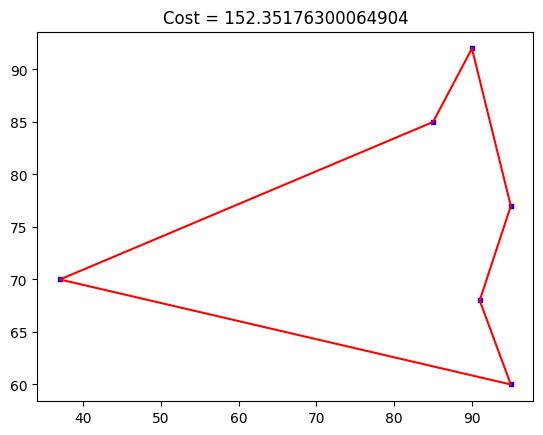

[1, 3, 6, 5, 4, 2] 152.35176300064904


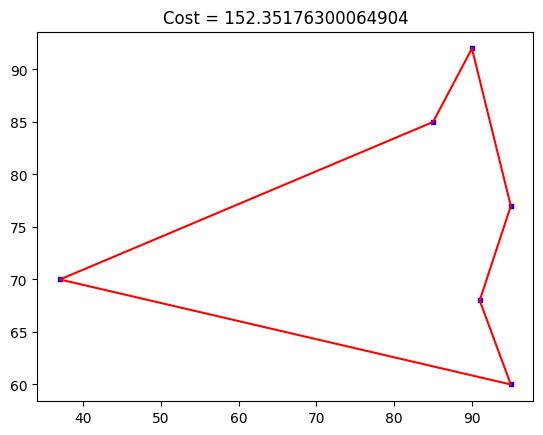

[1, 3, 6, 5, 4, 2] 152.35176300064904


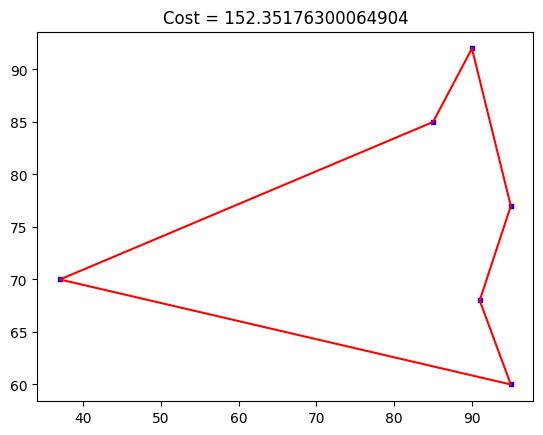

[1, 3, 6, 5, 4, 2] 152.35176300064904


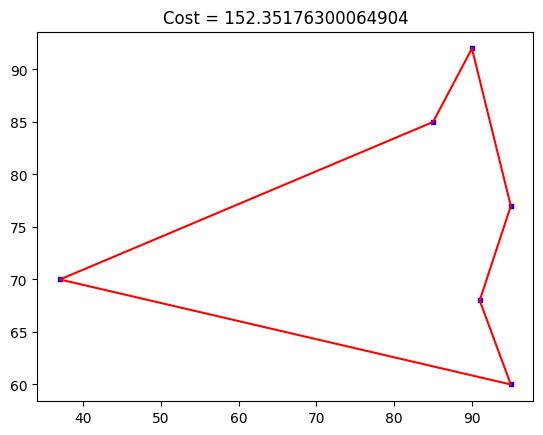

[1, 3, 6, 5, 4, 2] 152.35176300064904


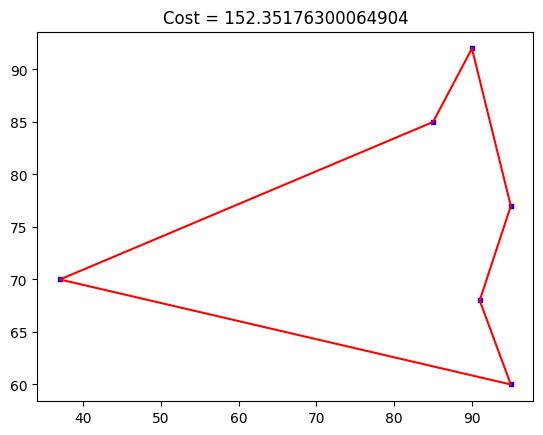

[1, 3, 6, 5, 4, 2] 152.35176300064904


In [9]:
###Example of a Genetic Algirthm for TSP

# PART 1 = Creates the Distance Matrix
# PART 2 = Plots the optimial route on a map.
# PART 3 = Calculates the distance of a given path
# PART 4 = Main GA parameters (Probability of creating each type of child)
# PART 5 = Carries out a Crossover
# PART 6 = Carries out a Mutation
# PART 7 = Selects the fittest parents
# PART 8 = Creates the new population for the next generation
# PART 9 = number of generations
# PART 10 =  Input the data for the problem
# PART 11 = Run the main GA (including population size)


import sys, math, random, heapq
import matplotlib.pyplot as plt
from itertools import chain

if sys.version_info < (3, 0):
   sys.exit("""Sorry, requires Python 3.x, not Python 2.x.""")

class Graph:

    def __init__(self, vertices):
        self.vertices = vertices
        self.n = len(vertices)

    def x(self, v):
        return self.vertices[v][0]

    def y(self, v):
        return self.vertices[v][1]

    # Lookup table for distances
    _d_lookup = {}

###########################################################################
##### PART 1: Converts grid co-ordinates of the nodes into a distance matrix

    def d(self, u, v):
        # Check if the distance was computed before
        if (u, v) in self._d_lookup:
            return self._d_lookup[(u, v)]
        # Otherwise compute euclidean distance
        _distance = math.sqrt((u[0] - v[0])**2 + (u[1] - v[1])**2)
        # Add to dictionary
        self._d_lookup[(u, v)], self._d_lookup[(v, u)] = _distance, _distance
        return _distance

###########################################################################
##### PART 2: Plots the final optimal route

    def plot(self, tour=None):
        """Plots the cities and superimposes given tour"""
        if tour is None:
            tour = Tour(self, [])

        _vertices = [self.vertices[0]]

        for i in tour.vertices:
            _vertices.append(self.vertices[i])

        _vertices.append(self.vertices[0])

        plt.title("Cost = " + str(tour.cost()))
        plt.plot(*zip(*_vertices), '-r')
        plt.scatter(*zip(*self.vertices), c="b", s=10, marker="s")
        plt.show()

###########################################################################
##### PART 3: Calculates the distance of a given (full) path
class Tour:

    def __init__(self, g, vertices = None):
        """Generate random tour in given graph g"""
        self.g = g
        if vertices is None:
            self.vertices = list(range(1, g.n))
            random.shuffle(self.vertices)
        else:
            self.vertices = vertices
        self.__cost = None

    def cost(self):
        """Return total edge-cost of tour"""
        if self.__cost is None:
            self.__cost = 0
            for i, j in zip([0] + self.vertices, self.vertices + [0]):
                self.__cost += self.g.d(self.g.vertices[i], self.g.vertices[j])
        return self.__cost

###########################################################################
##### PART 4: IMPORTANT Main GA parameters (Probability of creating each type of child)

class GeneticAlgorithm:

    def __init__(self, g, population_size, k=10, elite_mating_rate=0.2,
                 mutation_rate=0.2, mutation_swap_rate=0.2):   #Probability of each type of child being created
        """Initialises algorithm parameters"""

        self.g = g

        self.population = []
        for _ in range(population_size):
            self.population.append(Tour(g))

        self.population_size = population_size
        self.k = k
        self.elite_mating_rate = elite_mating_rate
        self.mutation_rate = mutation_rate
        self.mutation_swap_rate = mutation_swap_rate

###########################################################################
##### PART 5 = Crossover - as described in Teaching Material (Week 11 = AI)

    def crossover(self, mum, dad):
        """Implements ordered crossover"""

        size = len(mum.vertices)

        # Choose random start/end position for crossover
        alice, bob = [-1] * size, [-1] * size
        start, end = sorted([random.randrange(size) for _ in range(2)])

        # Replicate mum's sequence for alice, dad's sequence for bob
        for i in range(start, end + 1):
            alice[i] = mum.vertices[i]
            bob[i] = dad.vertices[i]

        # Fill the remaining position with the other parents' entries
        current_dad_position, current_mum_position = 0, 0

        for i in chain(range(start), range(end + 1, size)):

            while dad.vertices[current_dad_position] in alice:
                current_dad_position += 1

            while mum.vertices[current_mum_position] in bob:
                current_mum_position += 1

            alice[i] = dad.vertices[current_dad_position]
            bob[i] = mum.vertices[current_mum_position]

        # Return twins
        return Tour(self.g, alice), Tour(self.g, bob)

###########################################################################
##### PART 6 = Mutation - swaps pairs, as in TSP_HillClimb.py and described in Week 10, but can swap multiple pairs.
    def mutate(self, tour):
        """Randomly swaps pairs of cities in a given tour according to mutation rate"""

        # Decide whether to mutate
        if random.random() < self.mutation_rate:

            # For each vertex
            for i in range(len(tour.vertices)):

                # Randomly decide whether to swap node i
                if random.random() < self.mutation_swap_rate:

                    # Randomly choose other node to swap j
                    j = random.randrange(len(tour.vertices))

                    # Swap i and j
                    tour.vertices[i], tour.vertices[j] = tour.vertices[j], tour.vertices[i]

###########################################################################
##### PART 7 = Selects the fittest parents = takes a random sample of solutions and picks "best" solutions from that sample
    def select_parent(self, k):
        """Implements k-tournament selection to choose parents"""
        tournament = random.sample(self.population, k)
        return max(tournament, key=lambda t: t.cost())


###########################################################################
##### PART 8 = Creates the new population for the next generation

    def evolve(self):
        """Executes one iteration of the genetic algorithm to obtain a new generation"""

        new_population = []

        for _ in range(self.population_size):

            # K-tournament for parents
            mum, dad = self.select_parent(self.k), self.select_parent(self.k)
            alice, bob = self.crossover(mum, dad)

            # keep children if better than a parent
            if random.random() < self.elite_mating_rate:
                if alice.cost() < mum.cost() or alice.cost() < dad.cost():
                    new_population.append(alice)
                if bob.cost() < mum.cost() or bob.cost() < dad.cost():
                    new_population.append(bob)

            else:
                self.mutate(alice)
                self.mutate(bob)
                new_population += [alice, bob]

        # Add new population to old
        self.population += new_population

        # Take the fittest individuals in population, including Elitism
        self.population = heapq.nsmallest(self.population_size, self.population, key=lambda t: t.cost())

###########################################################################
##### PART 9 = IMPORTANT ##### number of generations = (similar to number of steps in hill-climb)

    def run(self, iterations=3600):  #Number of Generations: more = better, but takes longer
        for _ in range(iterations):
            self.evolve()

    def best(self):
        return max(self.population, key=lambda t: t.cost())

###########################################################################
##### PART 10 =  IMPORTANT ## Input the data for the problem

#Practical 9, Question 1
g = Graph([
#(35,16),    # 1
(90,92),     # 2
#(25,82),    # 3
(95,77),     # 4
(85,85),     # 5
#(51,37),    # 6
#(46,68),    # 7
#(31,43),    # 8
#(71,40),    # 9
(91,68),     # 10
#(68,29),    # 11
#(52,21),    # 12
#(57,44),    # 13
#(11,10),    # 14
#(41,45),    # 15
#(34,87),    # 16
#(26,41),    # 17
#(47,60),    # 18
#(58,9),     # 19
#(27,12),    # 20
#(9,92),     # 21
(95,60),     # 22
#(23,64),    # 23
#(21,25),     #W1
(37,70),     #W2
])

###########################################################################
##### PART 11 = IMPORTANT ## Runs the main GA (including population size)

for _ in range(5):  #Runs the GA 5 times
    ga = GeneticAlgorithm(g, 800)    #Inputs (graph co-ordinates, POPULATION SIZE)  more = better, but takes longer
    ga.run()


    ########## Output

    best_tour = ga.best()
    g.plot(best_tour)   #Plots the path on a graph

    best_path = best_tour.vertices
    size = len (g.vertices)
    for i in range(size-1):
        best_path[i]=best_path[i]+1   #Must +1 to nodes to chnage numbering from (0,n-1) to (1,n)
    best_path.insert(0,1)   #Adds start node to the list
    print(best_path,best_tour._Tour__cost)   #Prints the best path and distance

# W2 - Van 1. Route: W2 - 5 - 2 - 4 - 10 - 22 - W2 #

## Best:  152.35 ##

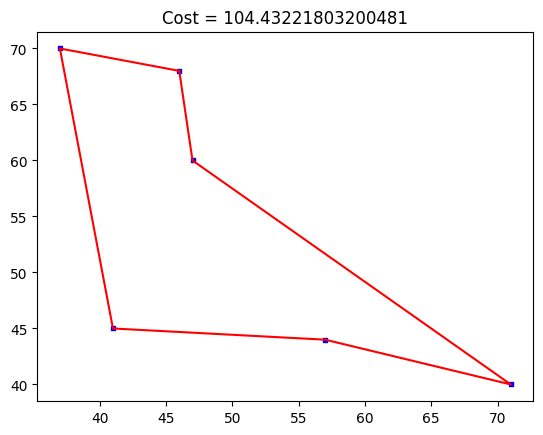

[1, 5, 2, 3, 4, 6] 104.43221803200481


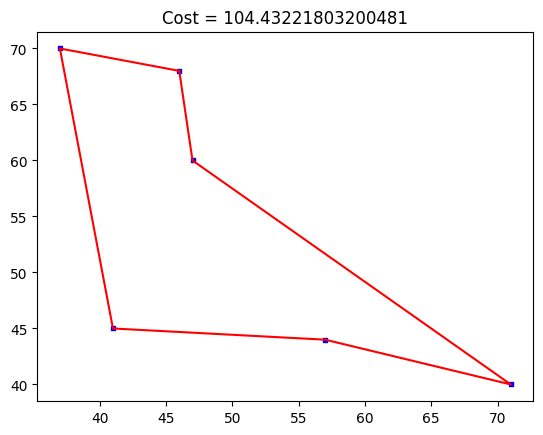

[1, 5, 2, 3, 4, 6] 104.43221803200481


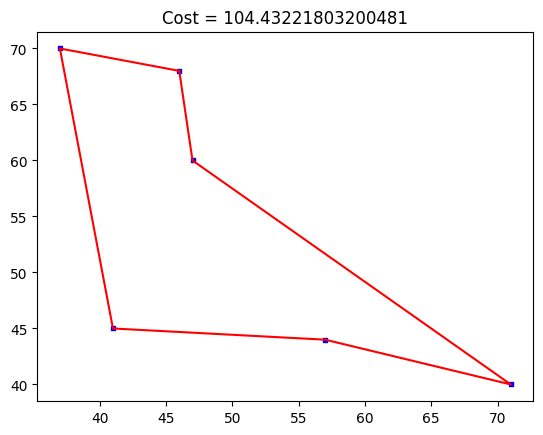

[1, 6, 4, 3, 2, 5] 104.43221803200481


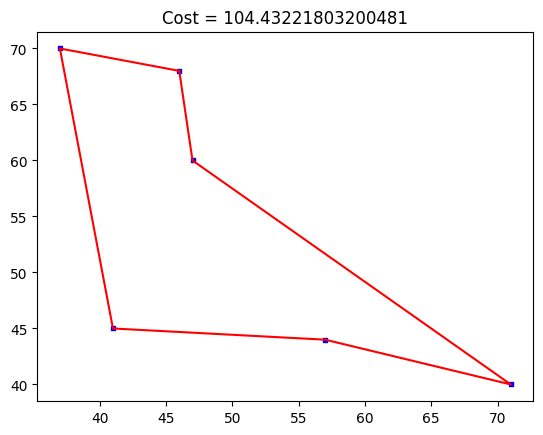

[1, 6, 4, 3, 2, 5] 104.43221803200481


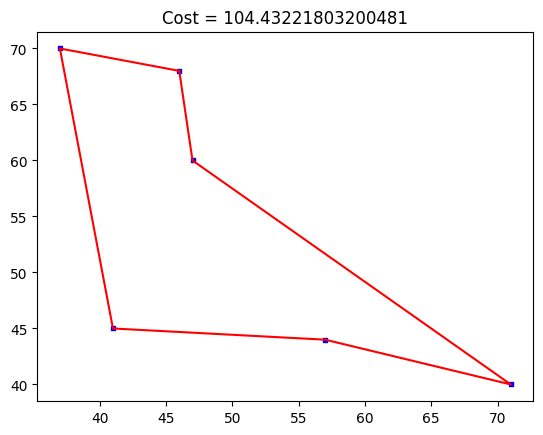

[1, 5, 2, 3, 4, 6] 104.43221803200481


In [10]:
###Example of a Genetic Algirthm for TSP

# PART 1 = Creates the Distance Matrix
# PART 2 = Plots the optimial route on a map.
# PART 3 = Calculates the distance of a given path
# PART 4 = Main GA parameters (Probability of creating each type of child)
# PART 5 = Carries out a Crossover
# PART 6 = Carries out a Mutation
# PART 7 = Selects the fittest parents
# PART 8 = Creates the new population for the next generation
# PART 9 = number of generations
# PART 10 =  Input the data for the problem
# PART 11 = Run the main GA (including population size)


import sys, math, random, heapq
import matplotlib.pyplot as plt
from itertools import chain

if sys.version_info < (3, 0):
   sys.exit("""Sorry, requires Python 3.x, not Python 2.x.""")

class Graph:

    def __init__(self, vertices):
        self.vertices = vertices
        self.n = len(vertices)

    def x(self, v):
        return self.vertices[v][0]

    def y(self, v):
        return self.vertices[v][1]

    # Lookup table for distances
    _d_lookup = {}

###########################################################################
##### PART 1: Converts grid co-ordinates of the nodes into a distance matrix

    def d(self, u, v):
        # Check if the distance was computed before
        if (u, v) in self._d_lookup:
            return self._d_lookup[(u, v)]
        # Otherwise compute euclidean distance
        _distance = math.sqrt((u[0] - v[0])**2 + (u[1] - v[1])**2)
        # Add to dictionary
        self._d_lookup[(u, v)], self._d_lookup[(v, u)] = _distance, _distance
        return _distance

###########################################################################
##### PART 2: Plots the final optimal route

    def plot(self, tour=None):
        """Plots the cities and superimposes given tour"""
        if tour is None:
            tour = Tour(self, [])

        _vertices = [self.vertices[0]]

        for i in tour.vertices:
            _vertices.append(self.vertices[i])

        _vertices.append(self.vertices[0])

        plt.title("Cost = " + str(tour.cost()))
        plt.plot(*zip(*_vertices), '-r')
        plt.scatter(*zip(*self.vertices), c="b", s=10, marker="s")
        plt.show()

###########################################################################
##### PART 3: Calculates the distance of a given (full) path
class Tour:

    def __init__(self, g, vertices = None):
        """Generate random tour in given graph g"""
        self.g = g
        if vertices is None:
            self.vertices = list(range(1, g.n))
            random.shuffle(self.vertices)
        else:
            self.vertices = vertices
        self.__cost = None

    def cost(self):
        """Return total edge-cost of tour"""
        if self.__cost is None:
            self.__cost = 0
            for i, j in zip([0] + self.vertices, self.vertices + [0]):
                self.__cost += self.g.d(self.g.vertices[i], self.g.vertices[j])
        return self.__cost

###########################################################################
##### PART 4: IMPORTANT Main GA parameters (Probability of creating each type of child)

class GeneticAlgorithm:

    def __init__(self, g, population_size, k=10, elite_mating_rate=0.2,
                 mutation_rate=0.2, mutation_swap_rate=0.2):   #Probability of each type of child being created
        """Initialises algorithm parameters"""

        self.g = g

        self.population = []
        for _ in range(population_size):
            self.population.append(Tour(g))

        self.population_size = population_size
        self.k = k
        self.elite_mating_rate = elite_mating_rate
        self.mutation_rate = mutation_rate
        self.mutation_swap_rate = mutation_swap_rate

###########################################################################
##### PART 5 = Crossover - as described in Teaching Material (Week 11 = AI)

    def crossover(self, mum, dad):
        """Implements ordered crossover"""

        size = len(mum.vertices)

        # Choose random start/end position for crossover
        alice, bob = [-1] * size, [-1] * size
        start, end = sorted([random.randrange(size) for _ in range(2)])

        # Replicate mum's sequence for alice, dad's sequence for bob
        for i in range(start, end + 1):
            alice[i] = mum.vertices[i]
            bob[i] = dad.vertices[i]

        # Fill the remaining position with the other parents' entries
        current_dad_position, current_mum_position = 0, 0

        for i in chain(range(start), range(end + 1, size)):

            while dad.vertices[current_dad_position] in alice:
                current_dad_position += 1

            while mum.vertices[current_mum_position] in bob:
                current_mum_position += 1

            alice[i] = dad.vertices[current_dad_position]
            bob[i] = mum.vertices[current_mum_position]

        # Return twins
        return Tour(self.g, alice), Tour(self.g, bob)

###########################################################################
##### PART 6 = Mutation - swaps pairs, as in TSP_HillClimb.py and described in Week 10, but can swap multiple pairs.
    def mutate(self, tour):
        """Randomly swaps pairs of cities in a given tour according to mutation rate"""

        # Decide whether to mutate
        if random.random() < self.mutation_rate:

            # For each vertex
            for i in range(len(tour.vertices)):

                # Randomly decide whether to swap node i
                if random.random() < self.mutation_swap_rate:

                    # Randomly choose other node to swap j
                    j = random.randrange(len(tour.vertices))

                    # Swap i and j
                    tour.vertices[i], tour.vertices[j] = tour.vertices[j], tour.vertices[i]

###########################################################################
##### PART 7 = Selects the fittest parents = takes a random sample of solutions and picks "best" solutions from that sample
    def select_parent(self, k):
        """Implements k-tournament selection to choose parents"""
        tournament = random.sample(self.population, k)
        return max(tournament, key=lambda t: t.cost())


###########################################################################
##### PART 8 = Creates the new population for the next generation

    def evolve(self):
        """Executes one iteration of the genetic algorithm to obtain a new generation"""

        new_population = []

        for _ in range(self.population_size):

            # K-tournament for parents
            mum, dad = self.select_parent(self.k), self.select_parent(self.k)
            alice, bob = self.crossover(mum, dad)

            # keep children if better than a parent
            if random.random() < self.elite_mating_rate:
                if alice.cost() < mum.cost() or alice.cost() < dad.cost():
                    new_population.append(alice)
                if bob.cost() < mum.cost() or bob.cost() < dad.cost():
                    new_population.append(bob)

            else:
                self.mutate(alice)
                self.mutate(bob)
                new_population += [alice, bob]

        # Add new population to old
        self.population += new_population

        # Take the fittest individuals in population, including Elitism
        self.population = heapq.nsmallest(self.population_size, self.population, key=lambda t: t.cost())

###########################################################################
##### PART 9 = IMPORTANT ##### number of generations = (similar to number of steps in hill-climb)

    def run(self, iterations=3700):  #Number of Generations: more = better, but takes longer
        for _ in range(iterations):
            self.evolve()

    def best(self):
        return max(self.population, key=lambda t: t.cost())

###########################################################################
##### PART 10 =  IMPORTANT ## Input the data for the problem

#Practical 9, Question 1
g = Graph([
#(35,16),    # 1
#(90,92),    # 2
#(25,82),    # 3
#(95,77),    # 4
#(85,85),    # 5
#(51,37),    # 6
(46,68),     # 7
#(31,43),    # 8
(71,40),     # 9
#(91,68),    # 10
#(68,29),    # 11
#(52,21),    # 12
(57,44),     # 13
#(11,10),    # 14
(41,45),     # 15
#(34,87),    # 16
#(26,41),    # 17
(47,60),     # 18
#(58,9),     # 19
#(27,12),    # 20
#(9,92),     # 21
#(95,60),    # 22
#(23,64),    # 23
#(21,25),     #W1
(37,70),     #W2
])

###########################################################################
##### PART 11 = IMPORTANT ## Runs the main GA (including population size)

for _ in range(5):  #Runs the GA 5 times
    ga = GeneticAlgorithm(g, 900)    #Inputs (graph co-ordinates, POPULATION SIZE)  more = better, but takes longer
    ga.run()


    ########## Output

    best_tour = ga.best()
    g.plot(best_tour)   #Plots the path on a graph

    best_path = best_tour.vertices
    size = len (g.vertices)
    for i in range(size-1):
        best_path[i]=best_path[i]+1   #Must +1 to nodes to chnage numbering from (0,n-1) to (1,n)
    best_path.insert(0,1)   #Adds start node to the list
    print(best_path,best_tour._Tour__cost)   #Prints the best path and distance

# W2 - Van 2. Route: W2 - 7 - 9 - 13 - 15 - 18 - W2

## Best:  104.43 ##

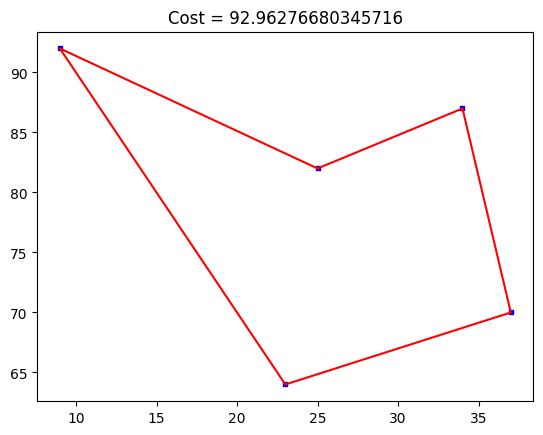

[1, 3, 4, 5, 2] 92.96276680345716


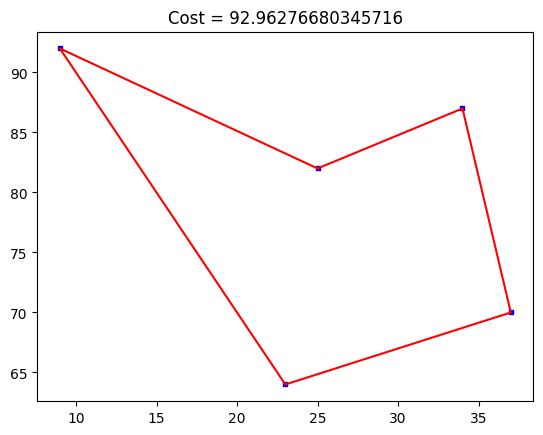

[1, 3, 4, 5, 2] 92.96276680345716


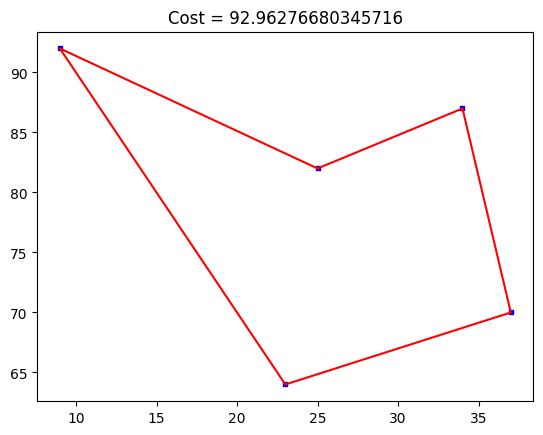

[1, 2, 5, 4, 3] 92.96276680345716


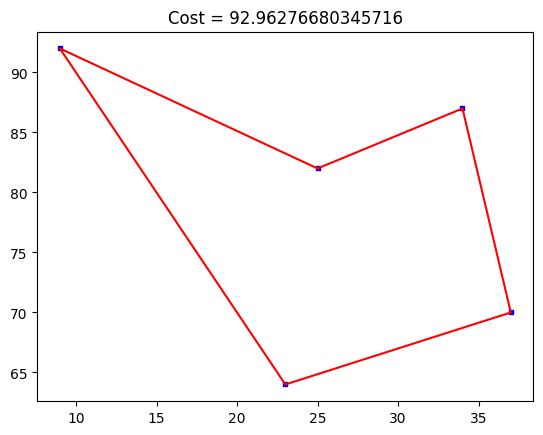

[1, 2, 5, 4, 3] 92.96276680345716


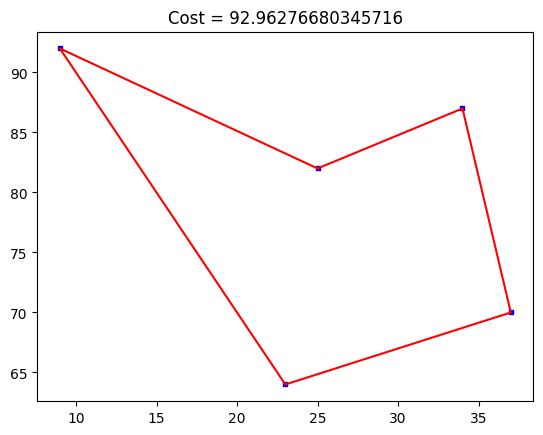

[1, 2, 5, 4, 3] 92.96276680345716


In [11]:
###Example of a Genetic Algirthm for TSP

# PART 1 = Creates the Distance Matrix
# PART 2 = Plots the optimial route on a map.
# PART 3 = Calculates the distance of a given path
# PART 4 = Main GA parameters (Probability of creating each type of child)
# PART 5 = Carries out a Crossover
# PART 6 = Carries out a Mutation
# PART 7 = Selects the fittest parents
# PART 8 = Creates the new population for the next generation
# PART 9 = number of generations
# PART 10 =  Input the data for the problem
# PART 11 = Run the main GA (including population size)


import sys, math, random, heapq
import matplotlib.pyplot as plt
from itertools import chain

if sys.version_info < (3, 0):
   sys.exit("""Sorry, requires Python 3.x, not Python 2.x.""")

class Graph:

    def __init__(self, vertices):
        self.vertices = vertices
        self.n = len(vertices)

    def x(self, v):
        return self.vertices[v][0]

    def y(self, v):
        return self.vertices[v][1]

    # Lookup table for distances
    _d_lookup = {}

###########################################################################
##### PART 1: Converts grid co-ordinates of the nodes into a distance matrix

    def d(self, u, v):
        # Check if the distance was computed before
        if (u, v) in self._d_lookup:
            return self._d_lookup[(u, v)]
        # Otherwise compute euclidean distance
        _distance = math.sqrt((u[0] - v[0])**2 + (u[1] - v[1])**2)
        # Add to dictionary
        self._d_lookup[(u, v)], self._d_lookup[(v, u)] = _distance, _distance
        return _distance

###########################################################################
##### PART 2: Plots the final optimal route

    def plot(self, tour=None):
        """Plots the cities and superimposes given tour"""
        if tour is None:
            tour = Tour(self, [])

        _vertices = [self.vertices[0]]

        for i in tour.vertices:
            _vertices.append(self.vertices[i])

        _vertices.append(self.vertices[0])

        plt.title("Cost = " + str(tour.cost()))
        plt.plot(*zip(*_vertices), '-r')
        plt.scatter(*zip(*self.vertices), c="b", s=10, marker="s")
        plt.show()

###########################################################################
##### PART 3: Calculates the distance of a given (full) path
class Tour:

    def __init__(self, g, vertices = None):
        """Generate random tour in given graph g"""
        self.g = g
        if vertices is None:
            self.vertices = list(range(1, g.n))
            random.shuffle(self.vertices)
        else:
            self.vertices = vertices
        self.__cost = None

    def cost(self):
        """Return total edge-cost of tour"""
        if self.__cost is None:
            self.__cost = 0
            for i, j in zip([0] + self.vertices, self.vertices + [0]):
                self.__cost += self.g.d(self.g.vertices[i], self.g.vertices[j])
        return self.__cost

###########################################################################
##### PART 4: IMPORTANT Main GA parameters (Probability of creating each type of child)

class GeneticAlgorithm:

    def __init__(self, g, population_size, k=10, elite_mating_rate=0.2,
                 mutation_rate=0.2, mutation_swap_rate=0.2):   #Probability of each type of child being created
        """Initialises algorithm parameters"""

        self.g = g

        self.population = []
        for _ in range(population_size):
            self.population.append(Tour(g))

        self.population_size = population_size
        self.k = k
        self.elite_mating_rate = elite_mating_rate
        self.mutation_rate = mutation_rate
        self.mutation_swap_rate = mutation_swap_rate

###########################################################################
##### PART 5 = Crossover - as described in Teaching Material (Week 11 = AI)

    def crossover(self, mum, dad):
        """Implements ordered crossover"""

        size = len(mum.vertices)

        # Choose random start/end position for crossover
        alice, bob = [-1] * size, [-1] * size
        start, end = sorted([random.randrange(size) for _ in range(2)])

        # Replicate mum's sequence for alice, dad's sequence for bob
        for i in range(start, end + 1):
            alice[i] = mum.vertices[i]
            bob[i] = dad.vertices[i]

        # Fill the remaining position with the other parents' entries
        current_dad_position, current_mum_position = 0, 0

        for i in chain(range(start), range(end + 1, size)):

            while dad.vertices[current_dad_position] in alice:
                current_dad_position += 1

            while mum.vertices[current_mum_position] in bob:
                current_mum_position += 1

            alice[i] = dad.vertices[current_dad_position]
            bob[i] = mum.vertices[current_mum_position]

        # Return twins
        return Tour(self.g, alice), Tour(self.g, bob)

###########################################################################
##### PART 6 = Mutation - swaps pairs, as in TSP_HillClimb.py and described in Week 10, but can swap multiple pairs.
    def mutate(self, tour):
        """Randomly swaps pairs of cities in a given tour according to mutation rate"""

        # Decide whether to mutate
        if random.random() < self.mutation_rate:

            # For each vertex
            for i in range(len(tour.vertices)):

                # Randomly decide whether to swap node i
                if random.random() < self.mutation_swap_rate:

                    # Randomly choose other node to swap j
                    j = random.randrange(len(tour.vertices))

                    # Swap i and j
                    tour.vertices[i], tour.vertices[j] = tour.vertices[j], tour.vertices[i]

###########################################################################
##### PART 7 = Selects the fittest parents = takes a random sample of solutions and picks "best" solutions from that sample
    def select_parent(self, k):
        """Implements k-tournament selection to choose parents"""
        tournament = random.sample(self.population, k)
        return max(tournament, key=lambda t: t.cost())


###########################################################################
##### PART 8 = Creates the new population for the next generation

    def evolve(self):
        """Executes one iteration of the genetic algorithm to obtain a new generation"""

        new_population = []

        for _ in range(self.population_size):

            # K-tournament for parents
            mum, dad = self.select_parent(self.k), self.select_parent(self.k)
            alice, bob = self.crossover(mum, dad)

            # keep children if better than a parent
            if random.random() < self.elite_mating_rate:
                if alice.cost() < mum.cost() or alice.cost() < dad.cost():
                    new_population.append(alice)
                if bob.cost() < mum.cost() or bob.cost() < dad.cost():
                    new_population.append(bob)

            else:
                self.mutate(alice)
                self.mutate(bob)
                new_population += [alice, bob]

        # Add new population to old
        self.population += new_population

        # Take the fittest individuals in population, including Elitism
        self.population = heapq.nsmallest(self.population_size, self.population, key=lambda t: t.cost())

###########################################################################
##### PART 9 = IMPORTANT ##### number of generations = (similar to number of steps in hill-climb)

    def run(self, iterations=3800):  #Number of Generations: more = better, but takes longer
        for _ in range(iterations):
            self.evolve()

    def best(self):
        return max(self.population, key=lambda t: t.cost())

###########################################################################
##### PART 10 =  IMPORTANT ## Input the data for the problem

#Practical 9, Question 1
g = Graph([
#(35,16),    # 1
#(90,92),    # 2
(25,82),     # 3
#(95,77),    # 4
#(85,85),    # 5
#(51,37),    # 6
#(46,68),    # 7
#(31,43),    # 8
#(71,40),    # 9
#(91,68),    # 10
#(68,29),    # 11
#(52,21),    # 12
#(57,44),    # 13
#(11,10),    # 14
#(41,45),    # 15
(34,87),     # 16
#(26,41),    # 17
#(47,60),    # 18
#(58,9),     # 19
#(27,12),    # 20
(9,92),      # 21
#(95,60),    # 22
(23,64),     # 23
#(21,25),     #W1
(37,70),     #W2
])

###########################################################################
##### PART 11 = IMPORTANT ## Runs the main GA (including population size)

for _ in range(5):  #Runs the GA 5 times
    ga = GeneticAlgorithm(g, 900)    #Inputs (graph co-ordinates, POPULATION SIZE)  more = better, but takes longer
    ga.run()


    ########## Output

    best_tour = ga.best()
    g.plot(best_tour)   #Plots the path on a graph

    best_path = best_tour.vertices
    size = len (g.vertices)
    for i in range(size-1):
        best_path[i]=best_path[i]+1   #Must +1 to nodes to chnage numbering from (0,n-1) to (1,n)
    best_path.insert(0,1)   #Adds start node to the list
    print(best_path,best_tour._Tour__cost)   #Prints the best path and distance

# W2 - Van 3. Route: W2 - 23 - 21 - 3 - 16 - W2

## Best: 92.96 ##

We now have all the best routes for each van in miles

- W1 Van A - 121.23
- W1 Van B - 87.55
- W2 Van A - 152.35
- W2 Vab B - 104.43
- W2 Van C - 92.96



Given the fact that I will be using just vans, which cost £2 per mile, the related running costs are:

- W1 Van A - 121.23 x2 = £242.46
- W1 Van B - 87.55 x2 = £175.10
- W2 Van A - 152.35 x2 = £304.70
- W2 Vab B - 104.43 x2 = £208.86
- W2 Van C - 92.96 x2 = £185.92

TOTAL DAILY COSTS FOR ALL THE VANS ON THE ROAD: £1117.04